In [1]:
import os
import re
from tqdm import tqdm

import numpy as np
import pandas as pd

import torch
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.feature_extraction.text import TfidfVectorizer

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
def explode_subjects(x):
    pattern = r'([^();]+) \(([\w.]+)\)'
    matches = re.findall(pattern, x)

    subject_list = []
    key_list = []

    for subject, key in matches:
        subject_list.append(subject.strip())
        key_list.append(key.strip())

    return subject_list, key_list

In [3]:
df = pd.read_parquet("arxiv_audio+recognition_search_term.parquet")
df.head()

,title,authors,abstract,Journal,code,submitted_date,orginally_announced_date,subjects
0,M&M: Multimodal-Multitask Model Integrating Au...,"Long Nguyen-Phuoc,Renald Gaboriau,Dimitri Dela...","This paper introduces the M&M model, a novel m...",Proceedings of the 19th International Joint Co...,arXiv:2403.09451,2024-03-14,2024-03-01,Computation and Language (cs.CL); Sound (cs.SD...
1,Unsupervised Modality-Transferable Video Highl...,"Tingtian Li,Zixun Sun,Xinyu Xiao",Identifying highlight moments of raw video mat...,None,arXiv:2403.09401,2024-03-14,2024-03-01,Sound (cs.SD); Computation and Language (cs.CL...
2,More than words: Advancements and challenges i...,Anna Kruspe,This paper addresses the challenges and advanc...,None,arXiv:2403.09298,2024-03-14,2024-03-01,Audio and Speech Processing (eess.AS); Computa...
3,SpeechColab Leaderboard: An Open-Source Platfo...,"Jiayu Du,Jinpeng Li,Guoguo Chen,Wei-Qiang Zhang",In the wake of the surging tide of deep learni...,None,arXiv:2403.08196,2024-03-12,2024-03-01,Audio and Speech Processing (eess.AS); Computa...
4,Automatic Speech Recognition (ASR) for the Dia...,"Taekyung Ahn,Yeonjung Hong,Younggon Im,Do Hyun...",This study presents a model of automatic speec...,None,arXiv:2403.08187,2024-03-12,2024-03-01,Computer Vision and Pattern Recognition (cs.CV...


In [4]:
all_subjects = []
all_keys = []

for val in tqdm(df['subjects'].values):
    subject_list, key_list = explode_subjects(val)

    all_subjects.extend(subject_list)
    all_keys.extend(key_list)

100%|██████████| 4000/4000 [00:00<00:00, 83561.86it/s]


In [5]:
abstracts = df['abstract'].tolist()

In [6]:
# Load the pre-trained model and tokenizer
model_name = "allenai/scibert_scivocab_uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

In [7]:
nltk.download('punkt')
nltk.download('stopwords')

stop_words = stopwords.words('english')
stemmer = PorterStemmer()

def preprocess_text(text):
  text = text.lower()
  text = ''.join([char for char in text if char.isalnum() or char in ' '])
  words = [word for word in text.split() if word not in stop_words]
  stemmed_words = [stemmer.stem(word) for word in words]
  return ' '.join(stemmed_words)

preprocessed_abstracts = [preprocess_text(text) for text in abstracts]

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\517\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\517\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
# Generate encoded abstracts
encoded_abstracts = tokenizer(abstracts, padding = True)
encoded_preprocessed_abstracts = tokenizer(preprocessed_abstracts, padding = True)

  File "c:\Users\517\anaconda3\envs\num_env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


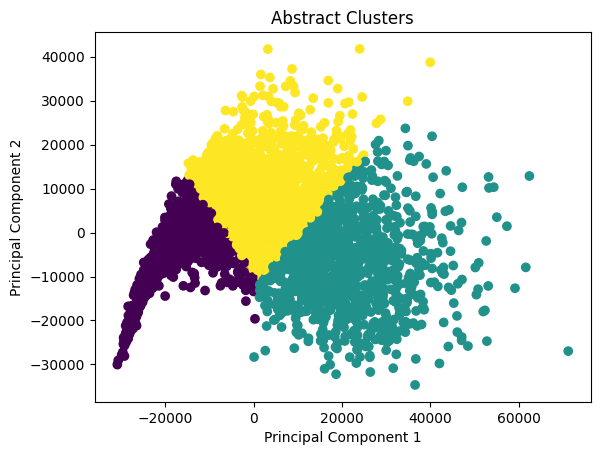

In [9]:
pca = PCA(n_components = 2)  # Reduce to 2 dimensions for visualization
pca_data = pca.fit_transform(encoded_abstracts['input_ids'])  # Use 'input_ids'

# Clustering (using KMeans here)
num_clusters = 3
kmeans = KMeans(n_clusters = num_clusters)
kmeans.fit(pca_data)
cluster_labels = kmeans.labels_

# Plot the clusters
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=cluster_labels)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Abstract Clusters")
plt.show()